# Purpose:
To demonstrate a simple method of classification using primary functions in sklearn.

## Background:
This example uses the traditional MNIST dataset of handwritten digits from high \
school students and US Census Bureau data. The general goal is to make the most \
accurate classification model that can classify digits from 0-9.

# Import Packages

In [235]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn functions
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay 



# Custom Functions

In [2]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')


# Fetch Data

In [3]:
from sklearn.datasets import fetch_openml

minst = fetch_openml('mnist_784', as_frame=False)

minst.data.shape

/opt/miniconda3/envs/homl3/lib/python3.10/site-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


(70000, 784)

In [4]:
# Define the input data and the labels
img_arrays, img_labels = minst.data, minst.target


5


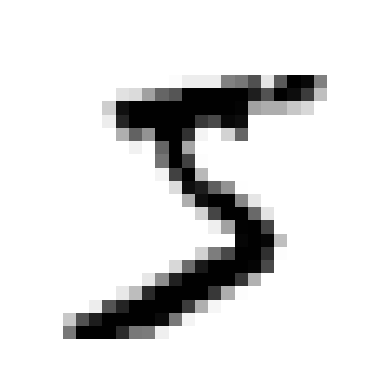

In [5]:
# Visualize the first image
print(img_labels[0])

example_img = img_arrays[0]
plot_digit(example_img)
plt.show()

The first digit is a 5, but it is difficult to determine visually.

# Make the training and test sets

In [6]:
# the MNIST training set is already shuffled an sampled. Therefore, we can just 
# reserve the first 60k images for training and the remainder 10k for testing.
x_train, x_test = img_arrays[:60000], img_arrays[60000:]
y_train, y_test = img_labels[:60000], img_labels[60000:]


# Model Testing
This testing a few different models to test which is the better model for \
categorizing these images into the correct digit.

## Dummy Classifier

For comparaison, it sometime useful to run a dummy classifier that uses simple \
rules to classify features to compare to trained models.

In [148]:

dummy_clf = DummyClassifier(strategy='stratified')

dummy_y_train_predict = cross_val_predict(dummy_clf, x_train, y_train, 
                                          cv=5,
                                          n_jobs=-1,
                                          verbose=1, 
                                          method='predict_proba')


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.0s remaining:    4.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.1s finished


In [151]:
#from sklearn.model_selection import cross_val_score

# Get cross-validation scores for the dummy classifier
dummy_scores = cross_val_score(dummy_clf, x_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Print the cross-validation scores
print("Cross-validation scores for Dummy Classifier:\n\t", dummy_scores)
print("\nMean cross-validation score for Dummy Classifier:\n\t", dummy_scores.mean())

Cross-validation scores for Dummy Classifier:
	 [0.09825    0.10191667 0.10183333 0.10116667 0.10258333]

Mean cross-validation score for Dummy Classifier:
	 0.10115


Since there is approximately equal representation of each digit within the data \
set, it is not surpising that the dummy classifier predicts the correct digit in \
about 1/10 times. However, when representation of a class is skewed (e.g. when \
training for just the digit '5' vs 'not 5'), a correct prediction could happen \
much more frequently (e.g. 9/10 times for the alternative example.)

## Logistic Regression

In [236]:
from sklearn.linear_model import LogisticRegression

# Create a logistic regression classifier
log_reg_clf = LogisticRegression(max_iter=1000, random_state=42)

# Predict the labels for the training set
log_reg_y_train_predict = cross_val_predict(log_reg_clf, x_train, y_train, cv=5, n_jobs=-1, verbose=1)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/opt/miniconda3/envs/homl3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/envs/homl3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solve

In [237]:
# Print the classification report
print("Classification Report:")
print(classification_report(y_train, log_reg_y_train_predict.astype(str)))

# Print the accuracy
print("Accuracy:", accuracy_score(y_train, log_reg_y_train_predict.astype(str)))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      5923
           1       0.95      0.97      0.96      6742
           2       0.90      0.88      0.89      5958
           3       0.89      0.89      0.89      6131
           4       0.92      0.91      0.92      5842
           5       0.88      0.85      0.87      5421
           6       0.93      0.95      0.94      5918
           7       0.93      0.92      0.92      6265
           8       0.87      0.87      0.87      5851
           9       0.88      0.90      0.89      5949

    accuracy                           0.91     60000
   macro avg       0.91      0.91      0.91     60000
weighted avg       0.91      0.91      0.91     60000

Accuracy: 0.9105166666666666


Not bad. A simple logistic regression classifier was much better than the dummy \
classifer that can accurately call the digit nearly 88% of the time. \
Let's look at the errors to see what digits the classifier struggles with the most \
and check out the precision and recall curves to see what the trade-off is for \
this classifier's thresholds.

### Error Exploration

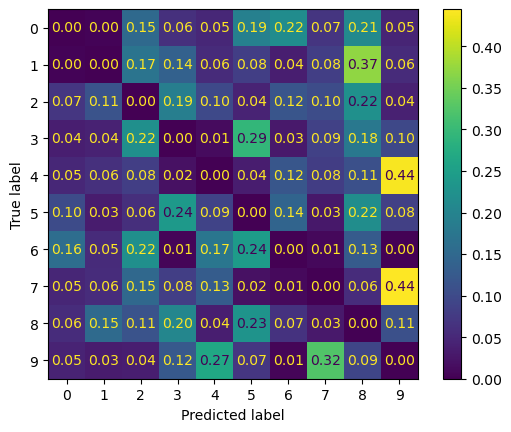

In [238]:
# Display the confusion matrix
sample_weight = (log_reg_y_train_predict.astype(str) != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, log_reg_y_train_predict.astype(str), 
                                        sample_weight=sample_weight,
                                        normalize='true', values_format='.2f')
plt.show()

The error plot is row normalized, and the high proportions show true/predicted digit combinations that are commonly missed. This shows that 4's and 7's are commonly mis-categorized as 9's. Additionally, a siginficant number of 1's were mis-categorized as 8's. 

Let's look at the precision and recall for the 9's classification:

### Precision and Recall Curves

<Figure size 600x400 with 0 Axes>

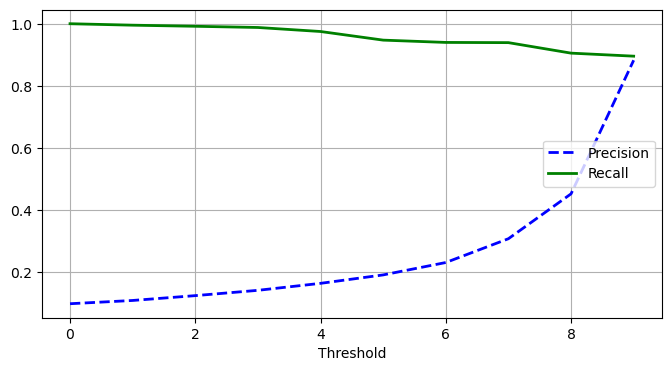

In [240]:
# Define the size of the figure
plt.figure(figsize=(6, 4))

# Define which digit category to plot
i = '9'

# Get the true binary labels for class 5
y_train_binary = (y_train == i).astype(int)

# Compute the precision-recall curve for class 5
precisions, recalls, thresholds = precision_recall_curve(y_train_binary, log_reg_y_train_predict.astype(int))

# Plot the precision-recall curve
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)


plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")


plt.show()

Interestingly, the precision and recall curves do not cross for the SGD model. \
This shows that the SGD model is overly tuned for a high recall (i.e. not missing \
any true positives) at the expense of precision (e.g. accidentially calling false \
negatives). In other words, the model is too conservative. 

This is further illustrated by the Reciever Operating Characteristic (ROC) Curve (below):

### ROC

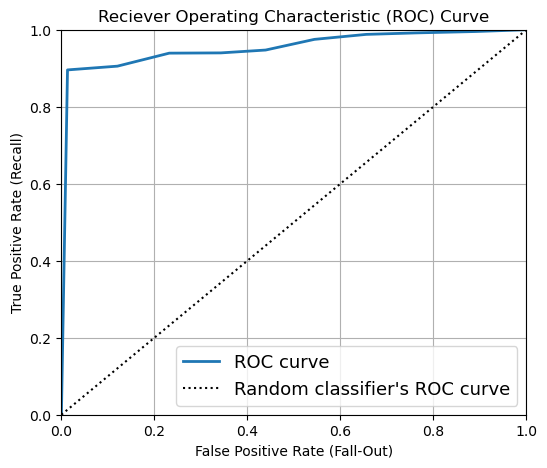

In [243]:

fpr, tpr, thresholds = roc_curve(y_train_binary, log_reg_y_train_predict.astype(int))

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.title('Reciever Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

The ROC curve illustrates that the the TPR and FPR for this model are quite good, \
but there is room for improvement. The TPR rapidly increases for the model, but \
quickly levels off around 0.9 showing that to capture the remaining correct digits \
will also increase the FPR drastically. 

Another model may be better.

## Stocastic Gradient Descent (SGD) Classifier

The SGD Classifier is another linear classifier that supports different loss functions. \
The default parameters for SGD Classifier includes a Hinge loss function (similar \
to SVMs) and a One-vs-Rest strategy for comparisons.

In [213]:
sgd_clf = SGDClassifier(random_state=42)

sgd_y_train_predict = cross_val_predict(sgd_clf, x_train, y_train,
                                        cv=5,
                                        n_jobs=-1,
                                        verbose=1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 12.0min remaining: 17.9min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 12.0min finished


In [214]:
# Print the classification report
print("Classification Report:")
print(classification_report(y_train, sgd_y_train_predict.astype(str)))

# Print the accuracy
print("Accuracy:", accuracy_score(y_train, sgd_y_train_predict.astype(str)))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5923
           1       0.93      0.96      0.95      6742
           2       0.88      0.86      0.87      5958
           3       0.87      0.84      0.86      6131
           4       0.88      0.88      0.88      5842
           5       0.83      0.81      0.82      5421
           6       0.92      0.94      0.93      5918
           7       0.91      0.89      0.90      6265
           8       0.81      0.80      0.80      5851
           9       0.82      0.84      0.83      5949

    accuracy                           0.88     60000
   macro avg       0.88      0.88      0.88     60000
weighted avg       0.88      0.88      0.88     60000

Accuracy: 0.8798


Interestingly, the SGD Classifier is worse that just simple linear regression. \
This could be further optimized through hyperparameterization, but it's more \
likely that it's better to try a different model that performs better just on the \
default parameters.

## SVC (Support Vector Classifier)
The SVC classifier natively uses the one-vs-one strategy when attempting to use \
a multi-classification model. This scales much better than the one-versus-all \
trategy for downstream learning.

In [245]:
svm_clf = SVC(random_state = 42, probability=True)

# Predict probabilities on the test set

y_train_prob = cross_val_predict(svm_clf, x_train, y_train, 
                                 cv=5, 
                                 n_jobs=-1, 
                                 verbose=1, 
                                 method='predict_proba')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 20.1min remaining: 30.2min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 20.3min finished


In [246]:
svc_y_train_predict = np.argmax(y_train_prob, axis=1)

# Print the classification report
print("Classification Report:")
print(classification_report(y_train, svc_y_train_predict.astype(str)))

# Print the accuracy
print("Accuracy:", accuracy_score(y_train, svc_y_train_predict.astype(str)))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5923
           1       0.99      0.99      0.99      6742
           2       0.98      0.98      0.98      5958
           3       0.97      0.97      0.97      6131
           4       0.97      0.98      0.97      5842
           5       0.97      0.97      0.97      5421
           6       0.99      0.99      0.99      5918
           7       0.98      0.98      0.98      6265
           8       0.97      0.97      0.97      5851
           9       0.97      0.96      0.97      5949

    accuracy                           0.98     60000
   macro avg       0.98      0.98      0.98     60000
weighted avg       0.98      0.98      0.98     60000

Accuracy: 0.9772666666666666


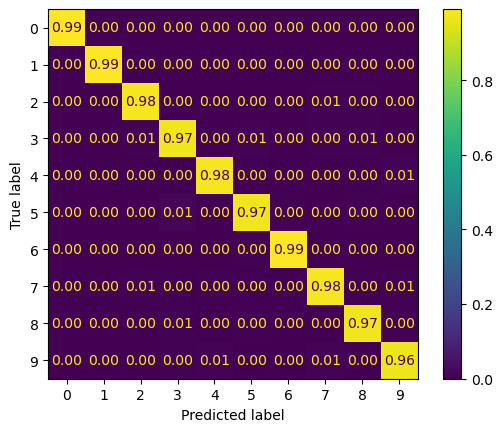

In [252]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_train, svc_y_train_predict.astype(str), 
                                        normalize='true', values_format='.2f')
plt.show()

In [249]:
# Get the precision threshold for 98% precision
idx_for_98_precision = (precisions >= 0.98).argmax()
threshold_for_98_precision = thresholds[idx_for_98_precision]
threshold_for_98_precision

0.6004192805004287

<Figure size 600x400 with 0 Axes>

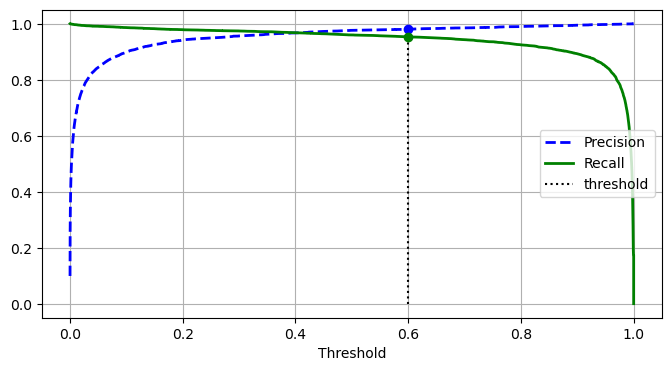

In [253]:
# Define the size of the figure
plt.figure(figsize=(6, 4))

# Define which digit category to plot
i = '9'

# Get the true binary labels for class 5
y_train_binary = (y_train == i).astype(int)

# Compute the precision-recall curve for class 5
precisions, recalls, thresholds = precision_recall_curve(y_train_binary, y_train_prob[:, int(i)])

# Plot the precision-recall curve
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold_for_98_precision, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold_for_98_precision).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
#plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")


plt.show()

### Precision-Recall Curve

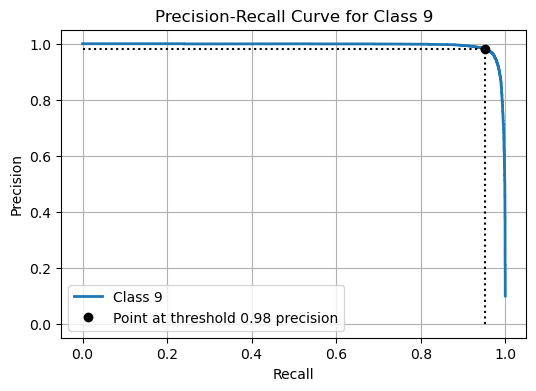

In [254]:
# Define the size of the figure
plt.figure(figsize=(6, 4))

# Define which digit category to plot
i = '9'

# Get the true binary labels for class 5
y_train_binary = (y_train == i).astype(int)

# Compute the precision-recall curve for class 5
precision, recall, _ = precision_recall_curve(y_train_binary, y_train_prob[:, int(i)])

# Plot the precision-recall curve
plt.plot(recall, precision, lw=2, label=f'Class {i}')
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 0.98 precision")


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for Class {i}')
plt.grid()
plt.legend(loc='best')
plt.show()

### ROC Curve

In [266]:
roc_auc = roc_auc_score(y_train_binary, y_train_prob[:, int(i)])

fpr, tpr, thresholds = roc_curve(y_train_binary, y_train_prob[:, int(i)])

roc_auc

0.9989552149652751

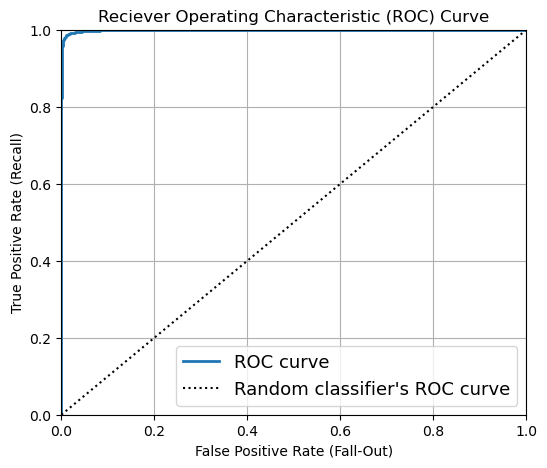

In [265]:
idx_for_threshold_at_98 = (thresholds <= threshold_for_98_precision).argmax()
tpr_98, fpr_98 = tpr[idx_for_threshold_at_98], fpr[idx_for_threshold_at_98]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.title('Reciever Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

The ROC curve is very good illustrating that for classifying 9's, the model does \
a great job at classifying almost all true positives before misclassifying false \
positive 9's. An AUC of 0.998 very close to filling up the full potential area \
above the 0.5 random binary classifier.

Normally, most models don't classify objects quite this well on the first pass \
and require downstream optimization of hyper parameterization. However, given the \
overall accuracy of the model, and the high F1 score for each digit category, \
this model could be quite good to deploy unless a higher accuracy model is required.